In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('titanic_data_updated.csv')

### 2. Analytical View of a Dataset

In [3]:
df.shape

print(f"Total potential features :{df.shape[1]}")
print(f"Total sample data :{df.shape[0]}")

Total potential features :12
Total sample data :891


In [4]:
df.head(10)

df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
262,263,no,first,"Taussig, Mr. Emil",male,52.0,1,1,110413,79.6500,E67,S
25,26,yes,third,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.0,1,5,347077,31.3875,NaN,S
564,565,no,third,"Meanwell, Miss. (Marion Ogden)",female,NaN,0,0,SOTON/O.Q. 392087,8.0500,NaN,S
784,785,no,third,"Ali, Mr. William",male,25.0,0,0,SOTON/O.Q. 3101312,7.0500,NaN,S
714,715,no,second,"Greenberg, Mr. Samuel",male,52.0,0,0,250647,13.0000,NaN,S
563,564,no,third,"Simmons, Mr. John",male,NaN,0,0,SOTON/OQ 392082,8.0500,NaN,S
348,349,yes,third,"Coutts, Master. William Loch ""William""",male,3.0,1,1,C.A. 37671,15.9000,NaN,S
724,725,yes,first,"Chambers, Mr. Norman Campbell",male,27.0,1,0,113806,53.1000,E8,S
723,724,no,second,"Hodges, Mr. Henry Price",male,50.0,0,0,250643,13.0000,NaN,S
680,681,no,third,"Peters, Miss. Katie",female,NaN,0,0,330935,8.1375,NaN,Q


Feature Screening

### 3. Feature Screening

In [5]:
# missing

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
# checking duplicates
df.duplicated().sum()

df.drop_duplicates(inplace=True)

S

### 4. Statistical Profiling

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [8]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


demo

### 5. Univariate Analysis( Categorical Value Analysis -1 )

<Axes: xlabel='Survived', ylabel='count'>

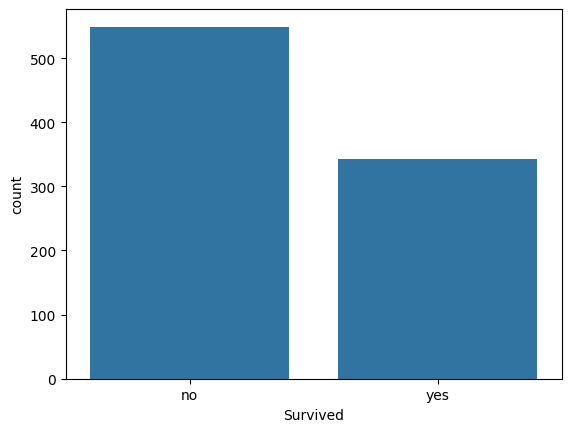

In [9]:
sns.countplot(data = df , x=df['Survived'])

In [10]:
(df['Survived'].value_counts() / len(df) ) * 100

Survived
no     61.616162
yes    38.383838
Name: count, dtype: float64

In [24]:
survived_count =  df['Survived'].value_counts()
survived_count

Survived
no     549
yes    342
Name: count, dtype: int64

In [25]:
survived_label = df['Survived'].unique()
survived_label

array(['no', 'yes'], dtype=object)

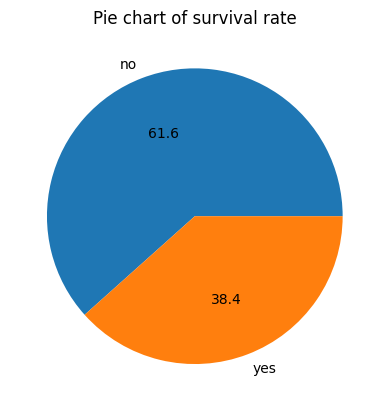

In [11]:
survived_count =  df['Survived'].value_counts()

survived_label = df['Survived'].unique()

plt.pie(survived_count, labels = survived_label, autopct="%1.1f")
plt.title('Pie chart of survival rate')
plt.show()

### 6. Univariate Analysis( Categorical Value Analysis -2)

<Axes: xlabel='Pclass', ylabel='count'>

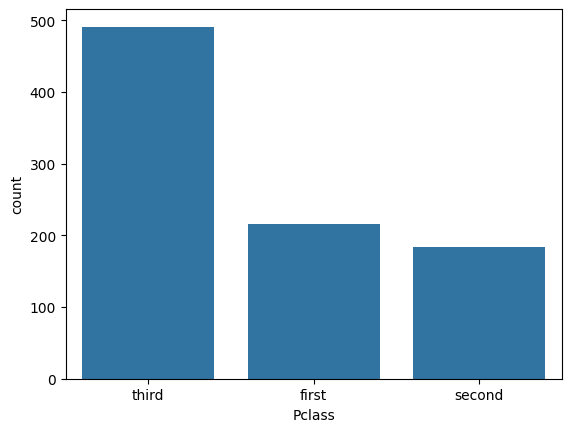

In [12]:
sns.countplot(data = df , x=df['Pclass'])

In [13]:
(df['Pclass'].value_counts() / len(df) ) * 100

Pclass
third     55.106622
first     24.242424
second    20.650954
Name: count, dtype: float64

<Axes: xlabel='Sex', ylabel='count'>

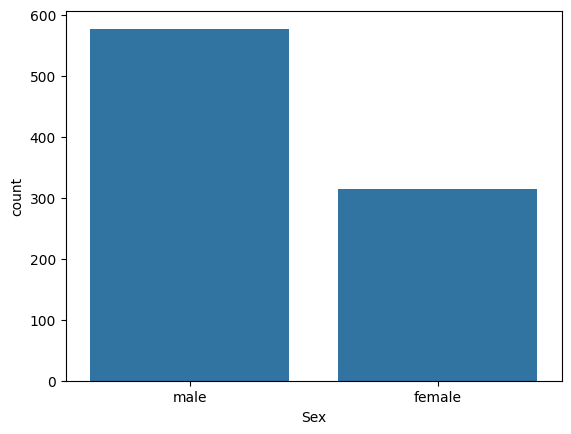

In [14]:
sns.countplot(data = df , x=df['Sex'])

In [15]:
(df['Sex'].value_counts() / len(df) ) * 100

Sex
male      64.758698
female    35.241302
Name: count, dtype: float64

<Axes: xlabel='Embarked', ylabel='count'>

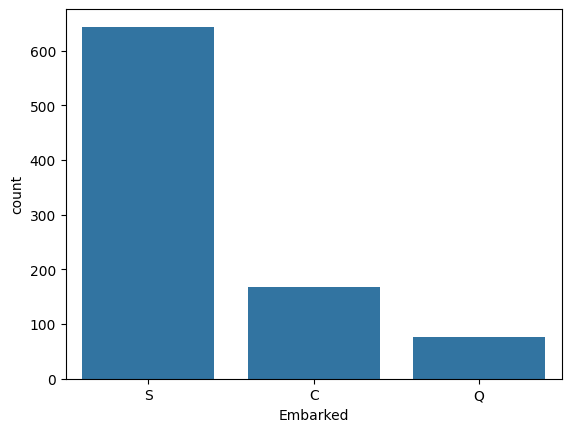

In [16]:
sns.countplot(data = df , x=df['Embarked'])

In [17]:
(df['Embarked'].value_counts() / len(df) ) * 100

Embarked
S    72.278339
C    18.855219
Q     8.641975
Name: count, dtype: float64

demo

### 7.Univariate Analysis ( Numerical Column Analysis - 1)

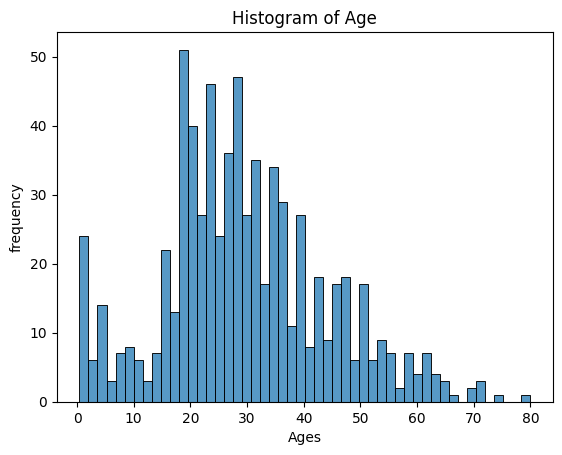

In [18]:
sns.histplot(df['Age'],bins=50)

plt.title('Histogram of Age')
plt.xlabel('Ages')
plt.ylabel('frequency')

plt.show()

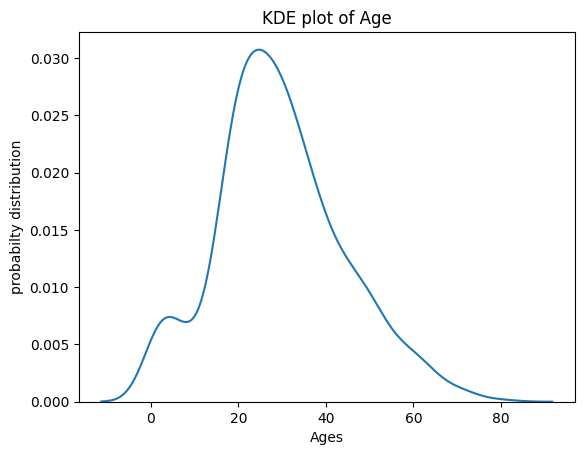

In [19]:
sns.kdeplot(df['Age'])
plt.title('KDE plot of Age')
plt.xlabel('Ages')
plt.ylabel('probabilty distribution')

plt.show()

### 8.Univariate Analysis ( Numerical Column Analysis - 2)

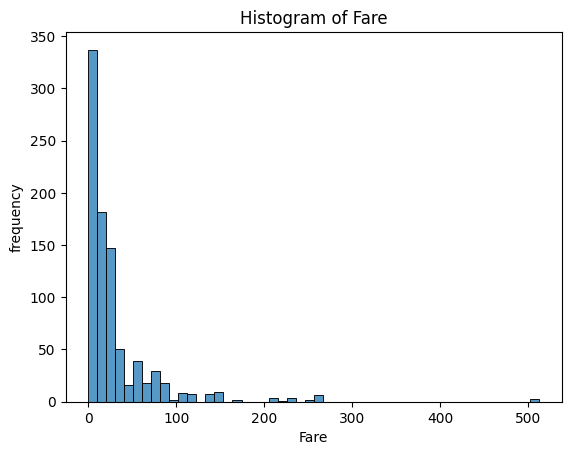

In [20]:
sns.histplot(df['Fare'],bins=50)

plt.title('Histogram of Fare')
plt.xlabel('Fare')
plt.ylabel('frequency')

plt.show()

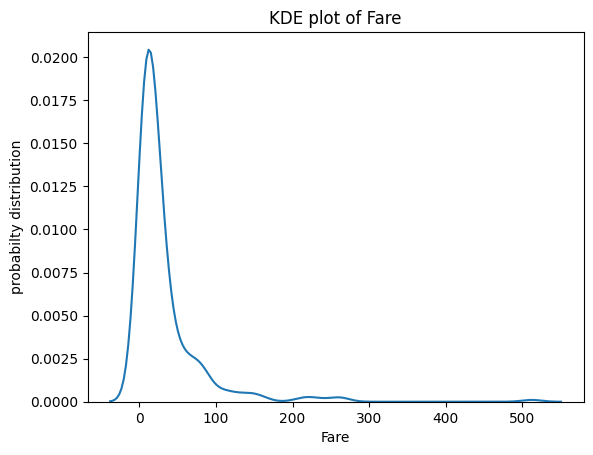

In [21]:
sns.kdeplot(df['Fare'])
plt.title('KDE plot of Fare')
plt.xlabel('Fare')
plt.ylabel('probabilty distribution')

plt.show()

<Axes: ylabel='Fare'>

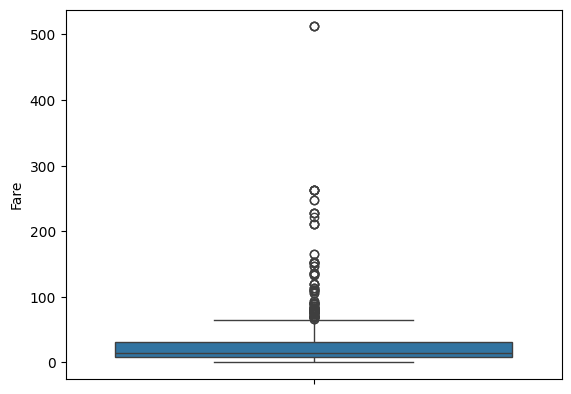

In [22]:
sns.boxplot(df['Fare'])